# Chương 4 — Mạng MLP

## Mô hình ban đầu

In [33]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from tensorflow import keras

keras.utils.set_random_seed(42)     # de chay lai cho cung ket qua
X, y = load_wine(return_X_y=True)   # X: (178, 13), y: 0 / 1 / 2

# Chia 64 / 16 / 20 %, giu nguyen ti le ba lop
X_tam, X_te, y_tam, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tam, y_tam, test_size=0.2, stratify=y_tam, random_state=42)
print(X_tr.shape, X_val.shape, X_te.shape)  # 113 / 29 / 36 mau

# Dung mang 13-64-32-3
model = keras.Sequential([
    keras.layers.Input(shape=(13,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(3, activation="softmax")])
model.compile(optimizer="sgd",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()                     # 3 075 tham so

history = model.fit(X_tr, y_tr, epochs=100, batch_size=16,
                    verbose=2, validation_data=(X_val, y_val))

loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f"Mat mat {loss:.4f} | do chinh xac {acc:.3f}")

(113, 13) (29, 13) (36, 13)


Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_137 (Dense)               │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_138 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 - 1s - 80ms/step - accuracy: 0.3805 - loss: 1389.6127 - val_accuracy: 0.4138 - val_loss: 1.0980
Epoch 2/100
8/8 - 0s - 13ms/step - accuracy: 0.3982 - loss: 1.0979 - val_accuracy: 0.4138 - val_loss: 1.0967
Epoch 3/100
8/8 - 0s - 13ms/step - accuracy: 0.3982 - loss: 1.0968 - val_accuracy: 0.4138 - val_loss: 1.0955
Epoch 4/100
8/8 - 0s - 13ms/step - accuracy: 0.3982 - loss: 1.0958 - val_accuracy: 0.4138 - val_loss: 1.0943
Epoch 5/100
8/8 - 0s - 13ms/step - accuracy: 0.3982 - loss: 1.0948 - val_accuracy: 0.4138 - val_loss: 1.0933
Epoch 6/100
8/8 - 0s - 13ms/step - accuracy: 0.3982 - loss: 1.0939 - val_accuracy: 0.4138 - val_loss: 1.0923
Epoch 7/100
8/8 - 0s - 14ms/step - accuracy: 0.3982 - loss: 1.0931 - val_accuracy: 0.4138 - val_loss: 1.0914
Epoch 8/100
8/8 - 0s - 14ms/step - accuracy: 0.3982 - loss: 1.0924 - val_accuracy: 0.4138 - val_loss: 1.0906
Epoch 9/100
8/8 - 0s - 13ms/step - accuracy: 0.3982 - loss: 1.0917 - val_accuracy: 0.4138 - val_loss: 1.0898
Epoch 10/100
8/8

## Đối chiếu số liệu  

In [34]:
import numpy as np

print("So tham so           :", model.count_params())
print("Tap huan luyen/kiem dinh/kiem tra: %d / %d / %d"
      % (len(X_tr), len(X_val), len(X_te)))
print("Mat mat epoch 1      : %.1f" % history.history["loss"][0])
print("Mat mat epoch 100    : %.4f   (ln 3 = %.4f)"
      % (history.history["loss"][-1], np.log(3)))
print("Do chinh xac kiem tra: %.4f" % acc)

y_dd = np.argmax(model.predict(X_te, verbose=0), axis=1)
print("So mau du doan vao moi lop:", np.bincount(y_dd, minlength=3))
print("So mau lop 1 that su co   : %d/%d" % ((y_te == 1).sum(), len(X_te)))


def con_song(m, Xd):
    """So no-ron con cho dau ra khac 0 voi it nhat mot mau, o hai lop an.

    Tinh thang tu trong so (Dense + ReLU) cho nhanh va khong lam Keras
    dung lai ham du doan nhieu lan."""
    a, ra = np.asarray(Xd, dtype="float32"), []
    for lop in m.layers[:2]:
        W, b = lop.get_weights()
        a = np.maximum(0.0, a @ W + b)
        ra.append(int((a.max(axis=0) > 0).sum()))
    return ra


print("Het 100 epoch: no-ron con song (lop 1, lop 2):", con_song(model, X_tr))

# ---- chay lai tu dau de do luc khoi tao va sau ba lo ----
keras.utils.set_random_seed(42)
m2 = keras.Sequential([
    keras.layers.Input(shape=(13,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(3, activation="softmax")])
m2.compile(optimizer="sgd", loss="sparse_categorical_crossentropy",
           metrics=["accuracy"])

W1, b1 = m2.layers[0].get_weights()
z1 = np.asarray(X_tr, dtype="float32") @ W1 + b1      # tong co trong so lop an 1
print("\nLuc khoi tao : |z| lon nhat = %.1f | no-ron con song %s"
      % (np.abs(z1).max(), con_song(m2, X_tr)))


class TungLo(keras.callbacks.Callback):
    """logs['loss'] la trung binh luy ke tu dau epoch, phai dat lai sau moi lo
    moi doc duoc mat mat cua rieng lo do."""

    def __init__(self):
        self.lo = []

    def on_train_batch_end(self, b, logs=None):
        self.lo.append(float(logs["loss"]))
        if b == 2:
            print("Sau ba lo dau: no-ron con song %s" % con_song(m2, X_tr))
        self.model.reset_metrics()


g = TungLo()
m2.fit(X_tr, y_tr, epochs=1, batch_size=16, verbose=0, callbacks=[g])
print("Mat mat cua tung lo trong epoch 1:", [round(v, 1) for v in g.lo])

So tham so           : 3075
Tap huan luyen/kiem dinh/kiem tra: 113 / 29 / 36
Mat mat epoch 1      : 1389.6
Mat mat epoch 100    : 1.0935   (ln 3 = 1.0986)
Do chinh xac kiem tra: 0.3889


So mau du doan vao moi lop: [ 0 36  0]
So mau lop 1 that su co   : 14/36
Het 100 epoch: no-ron con song (lop 1, lop 2): [0, 0]

Luc khoi tao : |z| lon nhat = 419.4 | no-ron con song [32, 16]
Sau ba lo dau: no-ron con song [2, 17]
Mat mat cua tung lo trong epoch 1: [60.1, 2021.5, 6368.2, 1361.1, 1.1, 1.1, 1.1, 1.1]


## đường học, độ chính xác và ma trận nhầm lẫn

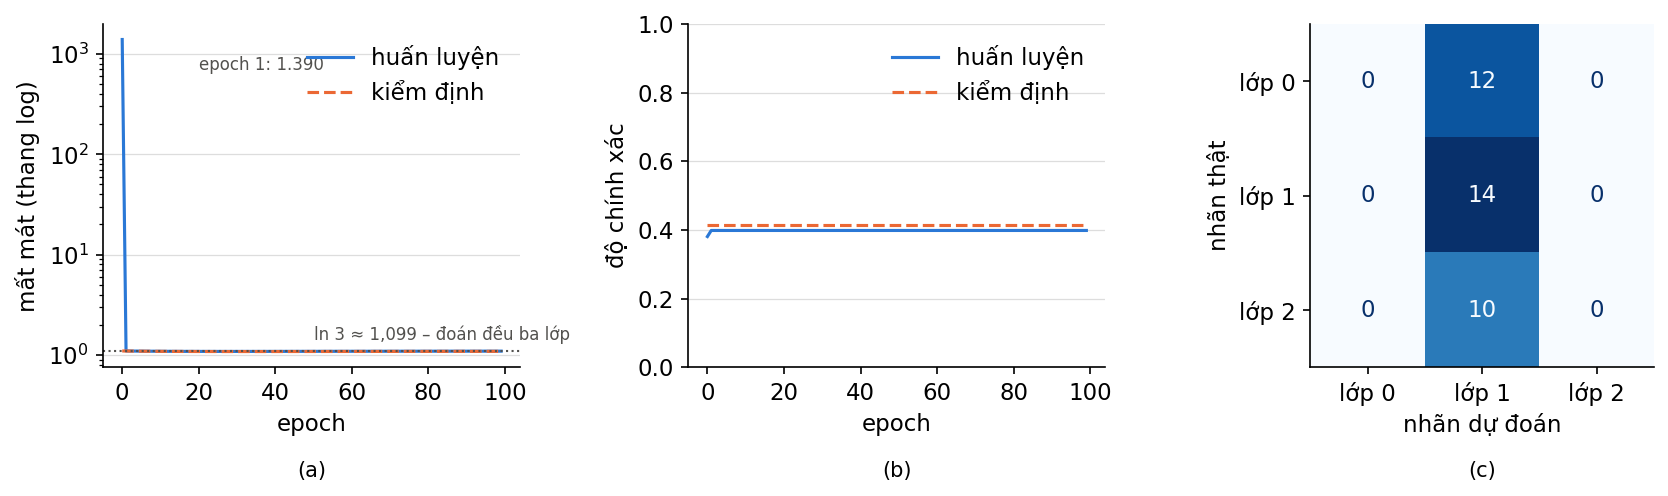

In [35]:
#
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

LAM, CAM, XAM = "#2A78D6", "#EB6834", "#52514E"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "figure.dpi": 150, "axes.spines.top": False,
                     "axes.spines.right": False})

y_dd = np.argmax(model.predict(X_te, verbose=0), axis=1)
fig, (t1, t2, t3) = plt.subplots(1, 3, figsize=(11.5, 3.9))

t1.semilogy(history.history["loss"], color=LAM, label="huấn luyện")
t1.semilogy(history.history["val_loss"], "--", color=CAM, label="kiểm định")
t1.axhline(np.log(3), color=XAM, lw=1, ls=":")
t1.text(50, np.log(3) * 1.3, "ln 3 ≈ 1,099 – đoán đều ba lớp", fontsize=8, color=XAM)
t1.text(20, history.history["loss"][0] * 0.5,
        "epoch 1: %s" % f"{round(history.history['loss'][0]):,}".replace(",", "."),
        fontsize=8, color=XAM)
t1.set_xlabel("epoch"); t1.set_ylabel("mất mát (thang log)")
t1.legend(frameon=False, loc="upper right")
t1.set_axisbelow(True); t1.grid(axis="y", color="#DDDDDD", lw=0.6)

t2.plot(history.history["accuracy"], color=LAM, label="huấn luyện")
t2.plot(history.history["val_accuracy"], "--", color=CAM, label="kiểm định")
t2.set_ylim(0, 1); t2.set_xlabel("epoch"); t2.set_ylabel("độ chính xác")
t2.legend(frameon=False, loc="upper right")
t2.set_axisbelow(True); t2.grid(axis="y", color="#DDDDDD", lw=0.6)

ConfusionMatrixDisplay(confusion_matrix(y_te, y_dd),
                       display_labels=["lớp 0", "lớp 1", "lớp 2"]
                       ).plot(ax=t3, cmap="Blues", colorbar=False, values_format="d")
t3.set_xlabel("nhãn dự đoán"); t3.set_ylabel("nhãn thật"); t3.grid(False)

for ax, nh in zip((t1, t2, t3), "abc"):
    ax.text(0.5, -0.32, "(%s)" % nh, transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## khoảng giá trị của 13 đặc trưng (thang log)

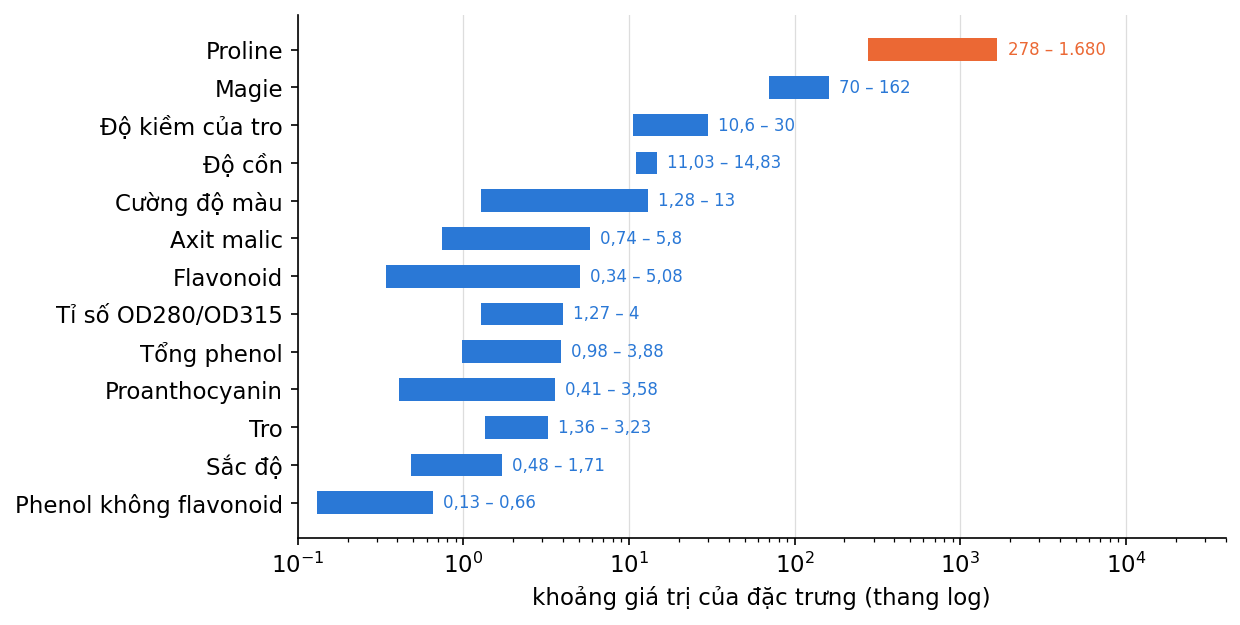

In [36]:
#
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

LAM, CAM = "#2A78D6", "#EB6834"
TEN = ["Độ cồn", "Axit malic", "Tro", "Độ kiềm của tro", "Magie", "Tổng phenol",
       "Flavonoid", "Phenol không flavonoid", "Proanthocyanin", "Cường độ màu",
       "Sắc độ", "Tỉ số OD280/OD315", "Proline"]


def sovn(v):
    """Viet so theo quy uoc Viet Nam: dau cham phan nhom nghin, dau phay thap phan."""
    v = round(float(v), 2)
    if abs(v - round(v)) < 1e-9:
        return f"{int(round(v)):,}".replace(",", ".")
    return ("%g" % v).replace(".", ",")


Xw = load_wine().data
lo, hi = Xw.min(axis=0), Xw.max(axis=0)
tt = np.argsort(hi)
fig, ax = plt.subplots(figsize=(8.4, 4.3))
for k, j in enumerate(tt):
    mau = CAM if TEN[j] == "Proline" else LAM
    ax.barh(k, hi[j] - lo[j], left=lo[j], color=mau, height=0.6)
    ax.text(hi[j] * 1.15, k, "%s – %s" % (sovn(lo[j]), sovn(hi[j])),
            va="center", ha="left", fontsize=8, color=mau)
ax.set_yticks(range(13)); ax.set_yticklabels([TEN[j] for j in tt])
ax.set_xscale("log"); ax.set_xlim(0.1, 4e4)
ax.set_xlabel("khoảng giá trị của đặc trưng (thang log)")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#DDDDDD", lw=0.6)
for c in ("top", "right"):
    ax.spines[c].set_visible(False)
plt.tight_layout(); plt.show()

## Sửa từng chỗ một rồi chạy lại

In [37]:
#
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras


def chia():
    X, y = load_wine(return_X_y=True)
    A, C, ya, yc = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    A, B, ya, yb = train_test_split(A, ya, test_size=0.2, stratify=ya, random_state=42)
    return A, B, C, ya, yb, yc


def thu(chuan=False, he=False, adam=False, dung_som=False, nhan=""):
    ds = []
    for s in range(5):
        keras.utils.set_random_seed(s)
        A, B, C, ya, yb, yc = chia()
        if chuan:
            sc = StandardScaler().fit(A)
            A, B, C = sc.transform(A), sc.transform(B), sc.transform(C)
        kt = "he_normal" if he else "glorot_uniform"
        m = keras.Sequential([
            keras.layers.Input(shape=(13,)),
            keras.layers.Dense(64, activation="relu", kernel_initializer=kt),
            keras.layers.Dense(32, activation="relu", kernel_initializer=kt),
            keras.layers.Dense(3, activation="softmax")])
        m.compile(optimizer=("adam" if adam else "sgd"),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                            restore_best_weights=True)] if dung_som else []
        m.fit(A, ya, epochs=100, batch_size=16, verbose=0,
              validation_data=(B, yb), callbacks=cb)
        ds.append(float(m.evaluate(C, yc, verbose=0)[1]))
    print("%-24s %.1f +- %.1f %%" % (nhan, 100 * np.mean(ds), 100 * np.std(ds)))


thu(nhan="du lieu tho")
thu(chuan=True, nhan="+ chuan hoa dau vao")
thu(chuan=True, he=True, adam=True, dung_som=True, nhan="+ ca bon cho")

du lieu tho              38.9 +- 0.0 %
+ chuan hoa dau vao      97.2 +- 0.0 %
+ ca bon cho             97.8 +- 1.1 %


## Chuẩn hoá đầu vào và chuẩn hoá theo lô

In [38]:
from sklearn.preprocessing import StandardScaler

# Chuan hoa dau vao: tham so chi uoc luong tren tap huan luyen
chuan_hoa = StandardScaler().fit(X_tr)
X_tr  = chuan_hoa.transform(X_tr)
X_val = chuan_hoa.transform(X_val)

# Chuan hoa theo lo: dat GIUA lop tuyen tinh va ham kich hoat
mang = keras.Sequential([
    keras.layers.Input(shape=(9,)),
    keras.layers.Dense(64),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.Dense(10, activation="softmax"),
])

## Chọn cách khởi tạo trọng số

In [39]:
# Lop an dung ReLU  -> khoi tao He
keras.layers.Dense(64, activation="relu",
                   kernel_initializer="he_normal")
# Lop ra dung Softmax -> khoi tao Xavier (mac dinh cua Keras)
keras.layers.Dense(10, activation="softmax",
                   kernel_initializer="glorot_uniform")

<Dense name=dense_191, built=False>

## Chọn bộ tối ưu và giảm dần tốc độ học

In [40]:
# Chon bo toi uu va dat toc do hoc
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Tu dong giam toc do hoc khi sai so kiem dinh ngung cai thien
giam_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
          epochs=200, callbacks=[giam_lr])

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.1593 - loss: 53.3833 - val_accuracy: 0.0690 - val_loss: 63.8109 - learning_rate: 0.0010
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1947 - loss: 47.9961 - val_accuracy: 0.1379 - val_loss: 58.2986 - learning_rate: 0.0010
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2124 - loss: 42.8767 - val_accuracy: 0.1379 - val_loss: 52.8862 - learning_rate: 0.0010
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2566 - loss: 38.0016 - val_accuracy: 0.1379 - val_loss: 47.5663 - learning_rate: 0.0010
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3097 - loss: 33.4293 - val_accuracy: 0.1379 - val_loss: 42.2944 - learning_rate: 0.0010
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3186 - loss: 29.0333 - val_accuracy: 0.1724 - val_loss: 37.0621 - learning_rate: 0.0010
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3717 - loss: 24.8177 - 

## Chính quy hoá: L2, Dropout và dừng sớm

In [41]:
from tensorflow.keras import regularizers

mang = keras.Sequential([
    keras.layers.Input(shape=(13,)), # Changed from 9 to 13 to match the wine dataset
    keras.layers.Dense(64, activation="relu",
                       kernel_regularizer=regularizers.l2(1e-4)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(3, activation="softmax"), # Changed from 10 to 3 to match the wine dataset classes
])

mang.compile(
    optimizer='adam', # A common optimizer for a good start
    loss='sparse_categorical_crossentropy', # Suitable for integer labels
    metrics=['accuracy']
)

dung_som = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True)
mang.fit(X_tr, y_tr, validation_data=(X_val, y_val),
         epochs=300, callbacks=[dung_som])

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.4159 - loss: 1.0877 - val_accuracy: 0.6207 - val_loss: 0.9552
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4248 - loss: 1.0680 - val_accuracy: 0.6552 - val_loss: 0.8757
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5487 - loss: 0.9390 - val_accuracy: 0.7931 - val_loss: 0.8050
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6195 - loss: 0.8527 - val_accuracy: 0.8276 - val_loss: 0.7382
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6991 - loss: 0.7946 - val_accuracy: 0.8621 - val_loss: 0.6773
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7788 - loss: 0.7175 - val_accuracy: 0.8621 - val_loss: 0.6214
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8053 - loss: 0.6461 - val_accuracy: 0.9310 - val_loss: 0.5692
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8761 - loss: 0.5993 - val_accuracy: 0.9310 - val_loss

## Chương trình đầy đủ

In [31]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

keras.utils.set_random_seed(7)   # de ket qua lap lai duoc

# Du lieu gia lap chi de chay thu khung ma: con so do chay
# ra khong co y nghia, bai toan that o muc 4.6
X, y = make_classification(n_samples=2000, n_features=9,
                           n_informative=6, n_classes=10,
                           random_state=7)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=7)

# Chuan hoa: uoc luong tren tap huan luyen roi ap lai
bo_chuan = StandardScaler().fit(X_tr)
X_tr = bo_chuan.transform(X_tr)
X_te = bo_chuan.transform(X_te)

model = keras.Sequential([
    keras.layers.Input(shape=(X_tr.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

dung_som = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10,
    restore_best_weights=True)
luu_tot = keras.callbacks.ModelCheckpoint(
    "mang_tot_nhat.keras", monitor="val_loss",
    save_best_only=True)

history = model.fit(X_tr, y_tr, validation_split=0.2,
                    epochs=100, batch_size=32, verbose=2,
                    callbacks=[dung_som, luu_tot])
                    # them class_weight=... neu lech lop

loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f"Do chinh xac tren tap kiem tra: {acc:.3f}")
model.save("mang_cuoi.keras")

Epoch 1/100
40/40 - 1s - 34ms/step - accuracy: 0.1273 - loss: 2.3006 - val_accuracy: 0.1469 - val_loss: 2.2377
Epoch 2/100
40/40 - 0s - 5ms/step - accuracy: 0.2172 - loss: 2.1677 - val_accuracy: 0.2656 - val_loss: 2.1178
Epoch 3/100
40/40 - 0s - 5ms/step - accuracy: 0.3008 - loss: 2.0400 - val_accuracy: 0.3281 - val_loss: 1.9830
Epoch 4/100
40/40 - 0s - 5ms/step - accuracy: 0.3492 - loss: 1.9149 - val_accuracy: 0.3750 - val_loss: 1.8603
Epoch 5/100
40/40 - 0s - 5ms/step - accuracy: 0.3625 - loss: 1.8226 - val_accuracy: 0.4187 - val_loss: 1.7715
Epoch 6/100
40/40 - 0s - 5ms/step - accuracy: 0.3898 - loss: 1.7482 - val_accuracy: 0.4500 - val_loss: 1.7094
Epoch 7/100
40/40 - 0s - 5ms/step - accuracy: 0.4102 - loss: 1.7038 - val_accuracy: 0.4563 - val_loss: 1.6607
Epoch 8/100
40/40 - 0s - 5ms/step - accuracy: 0.4219 - loss: 1.6500 - val_accuracy: 0.4625 - val_loss: 1.6209
Epoch 9/100
40/40 - 0s - 5ms/step - accuracy: 0.4437 - loss: 1.6077 - val_accuracy: 0.4812 - val_loss: 1.5884
Epoch 10/

## Vẽ đồ thị

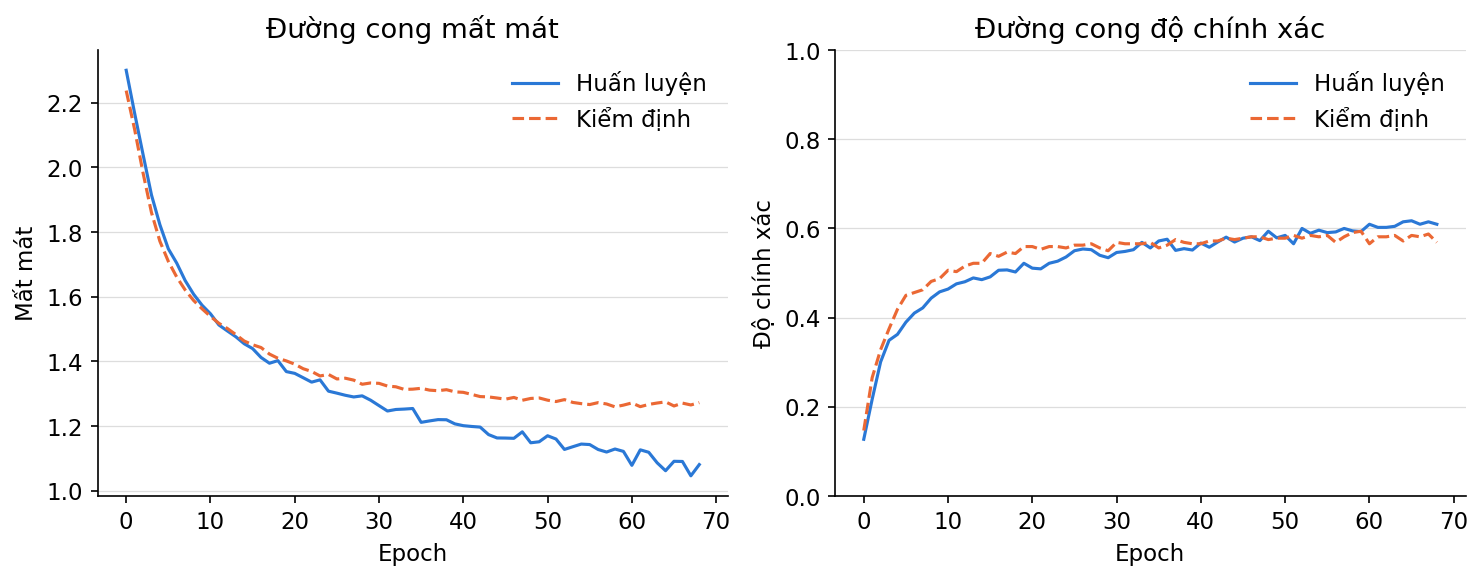

In [32]:
import matplotlib.pyplot as plt

LAM, CAM = "#2A78D6", "#EB6834"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "figure.dpi": 150, "axes.spines.top": False,
                     "axes.spines.right": False})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot training and validation loss
ax1.plot(history.history["loss"], color=LAM, label="Huấn luyện")
ax1.plot(history.history["val_loss"], "--", color=CAM, label="Kiểm định")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Mất mát")
ax1.set_title("Đường cong mất mát")
ax1.legend(frameon=False, loc="upper right")
ax1.set_axisbelow(True); ax1.grid(axis="y", color="#DDDDDD", lw=0.6)

# Plot training and validation accuracy
ax2.plot(history.history["accuracy"], color=LAM, label="Huấn luyện")
ax2.plot(history.history["val_accuracy"], "--", color=CAM, label="Kiểm định")
ax2.set_ylim(0, 1)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Độ chính xác")
ax2.set_title("Đường cong độ chính xác")
ax2.legend(frameon=False, loc="upper right")
ax2.set_axisbelow(True); ax2.grid(axis="y", color="#DDDDDD", lw=0.6)

plt.tight_layout()
plt.show()